In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np

from quantem.core.visualization import show_2d
from quantem.tomography.utils import rot_ZXZ

/home/cedlim/quantem/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Creating Phantom Dataset
Cedric Lim, *12/5/2025*

**Note: Requires the tomography branch (TEMP)**

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

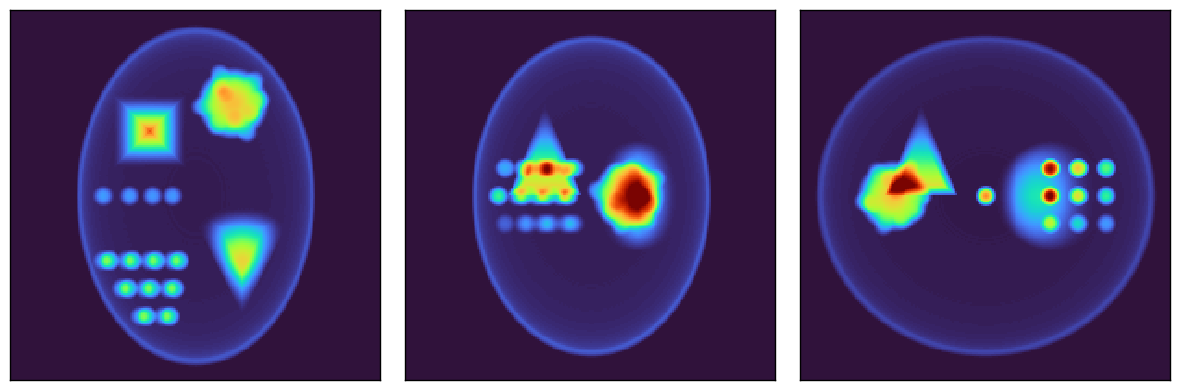

In [3]:
# Load phantom volume

phantom_vol = torch.from_numpy(np.load('../../../data/phantom.npy')).type(torch.float32)

show_2d(
    [phantom_vol.sum(axis = 0),
     phantom_vol.sum(axis = 1),
     phantom_vol.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = 50
)


## Simulate tilt series dataset

Create a tilt series dataset with a tilt step of 4 degrees, tilt range of (-70, 70). with a 1 degree systematic tilt axis error

In [18]:
tilt_step = 5
tilt_angles = torch.arange(-70, 71, tilt_step).type(torch.float32)
tilt_series = []
tilt_axis = 1

for tilt_angle in tilt_angles:
    tilt_series.append(rot_ZXZ(phantom_vol.unsqueeze(0), z1 = tilt_axis, x = tilt_angle, z3 = -tilt_axis, device = 'cpu').squeeze(0).sum(axis = 0))

tilt_series = torch.stack(tilt_series)
print("Tilt series shape: ", tilt_series.shape)
print(tilt_angles)

/home/cedlim/quantem/quantem/src/quantem/tomography/utils.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=device)


Tilt series shape:  torch.Size([29, 200, 200])
tensor([-70., -65., -60., -55., -50., -45., -40., -35., -30., -25., -20., -15.,
        -10.,  -5.,   0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,
         50.,  55.,  60.,  65.,  70.])


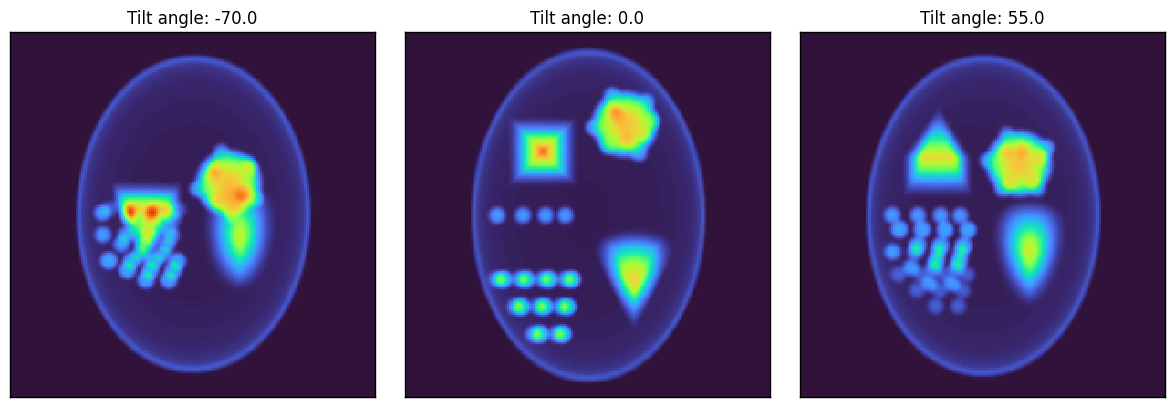

In [24]:
fig, ax = show_2d(
    [tilt_series[0], tilt_series[14], tilt_series[25]],
    titles = ['Tilt angle: {}'.format(tilt_angles[0]),
              'Tilt angle: {}'.format(tilt_angles[14]),
              'Tilt angle: {}'.format(tilt_angles[25])],
    cmap = 'turbo',
    vmin = 0,
    vmax = 50
)


# Saving Simulated Data

In [25]:
np.save('../../../data/tilt_series_1_deg_tilt_axis.npy', tilt_series)
np.save('../../../data/tilt_angles_1_deg_tilt_axis.npy', tilt_angles)